Generating Finance Invoice Agent Flowchart...


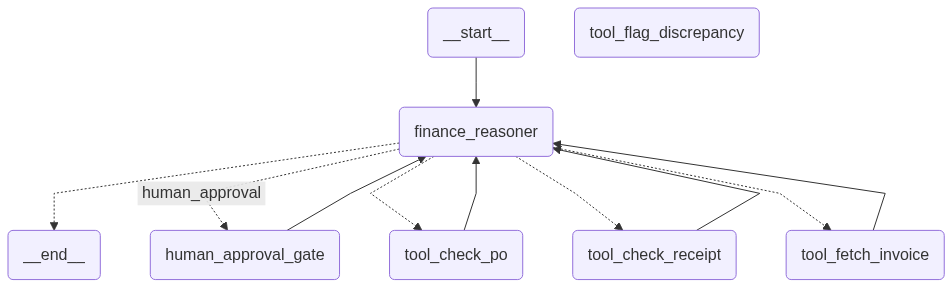


--- Starting Financial Audit Cycle ---
Node Executed: finance_reasoner
Message: Fetching supplier invoice details...

Node Executed: tool_fetch_invoice
Message: Invoice INV-2026-990: Item 'Steel Sheet 3mm', Quantity: 500 units, Unit Price: $50, Total: $25,000

Node Executed: finance_reasoner
Message: Cross-referencing invoice against Purchase Order...

Node Executed: tool_check_po
Message: PO Record: Item 'Steel Sheet 3mm', Approved Quantity: 500 units, Agreed Unit Price: $50

Node Executed: finance_reasoner
Message: Verifying warehouse delivery receipt...

Node Executed: tool_check_receipt
Message: Delivery Receipt for INV-2026-990: Physically received quantity: 450 units (Shortage of 50 units)

Node Executed: finance_reasoner
Message: Mismatch caught: Invoice claims 500 units, but delivery receipt confirms only 450 units received. Flagging for financial review.


--- FINANCIAL APPROVAL REQUIRED ---
Agent detected an invoice mismatch and paused the payment.
Supervisor Action: Approve

In [ ]:
# ---------------------------------------------------------
# 06_Finance_Invoice_Agent.ipynb
# LangGraph Implementation for Finance Invoice Cross-Checking
# ---------------------------------------------------------

import operator
from typing import TypedDict, Annotated, Sequence
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, ToolMessage
from langgraph.graph import StateGraph, END, START
from IPython.display import Image, display

# 1. Define the Graph State for Financial Audit
class FinanceInvoiceState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], operator.add]
    invoice_id: str
    invoice_data: dict
    po_data: dict
    receipt_data: dict
    discrepancy_found: bool
    approval_status: str # Maps to workflow_history.approval_status[cite: 5]
    next_step: str

# 2. Mocking Financial & ERP Tools (Mapped to backend_api_table)
def fetch_supplier_invoice(invoice_id: str) -> str:
    """Fetches invoice details: quantity, pricing, and supplier info."""
    return f"Invoice {invoice_id}: Item 'Steel Sheet 3mm', Quantity: 500 units, Unit Price: $50, Total: $25,000"

def check_purchase_order(item_name: str) -> str:
    """Fetches the corresponding Purchase Order (PO) specs."""
    return f"PO Record: Item '{item_name}', Approved Quantity: 500 units, Agreed Unit Price: $50"

def check_delivery_receipt(invoice_id: str) -> str:
    """Fetches the physical warehouse delivery receipt log."""
    return f"Delivery Receipt for {invoice_id}: Physically received quantity: 450 units (Shortage of 50 units)"

def flag_discrepancy_and_notify(details: str) -> str:
    """Flags a financial mismatch and holds the payment queue."""
    return f"DISCREPANCY FLAGGED: {details}. Payment paused pending supervisor approval."

# 3. Define the Nodes
def finance_reasoner(state: FinanceInvoiceState):
    """
    Node 1: Financial Auditor Reasoner.
    Sequentially fetches invoice, PO, and delivery receipt data to detect mismatches.
    """
    # Step 1: Fetch Invoice
    if not state.get('invoice_data'):
        return {
            "messages": [AIMessage(content="Fetching supplier invoice details...", tool_calls=[{"name": "fetch_supplier_invoice", "args": {"invoice_id": state['invoice_id']}, "id": "inv_call_1"}])],
            "next_step": "tool_fetch_invoice"
        }
    
    # Step 2: Check Purchase Order
    elif not state.get('po_data'):
        return {
            "messages": [AIMessage(content="Cross-referencing invoice against Purchase Order...", tool_calls=[{"name": "check_purchase_order", "args": {"item_name": "Steel Sheet 3mm"}, "id": "po_call_1"}])],
            "next_step": "tool_check_po"
        }
    
    # Step 3: Check Delivery Receipt
    elif not state.get('receipt_data'):
        return {
            "messages": [AIMessage(content="Verifying warehouse delivery receipt...", tool_calls=[{"name": "check_delivery_receipt", "args": {"invoice_id": state['invoice_id']}, "id": "rcpt_call_1"}])],
            "next_step": "tool_check_receipt"
        }
    
    # Step 4: Evaluate for Mismatches
    elif not state.get('discrepancy_found'):
        # In a live agent, the LLM evaluates the text strings. Here we mock the discrepancy catch.
        return {
            "messages": [AIMessage(content="Mismatch caught: Invoice claims 500 units, but delivery receipt confirms only 450 units received. Flagging for financial review.", tool_calls=[{"name": "flag_discrepancy_and_notify", "args": {"details": "Invoice quantity (500) vs Delivered quantity (450) mismatch"}, "id": "flag_call_1"}])],
            "discrepancy_found": True,
            "approval_status": "Pending",
            "next_step": "human_approval"
        }
    
    # Step 5: Finalize after Human Approval
    elif state.get('approval_status') == 'Approved':
        return {
            "messages": [AIMessage(content="Financial adjustment recorded. Debit note generated for the 50 missing units.")],
            "next_step": "end"
        }
    
    return {"next_step": "end"}

def tool_fetch_invoice(state: FinanceInvoiceState):
    last_msg = state['messages'][-1]
    tool_call = last_msg.tool_calls[0]
    result = fetch_supplier_invoice(tool_call['args']['invoice_id'])
    return {"messages": [ToolMessage(content=result, tool_call_id=tool_call['id'])], "invoice_data": {"raw": result}, "next_step": "reasoner"}

def tool_check_po(state: FinanceInvoiceState):
    last_msg = state['messages'][-1]
    tool_call = last_msg.tool_calls[0]
    result = check_purchase_order(tool_call['args']['item_name'])
    return {"messages": [ToolMessage(content=result, tool_call_id=tool_call['id'])], "po_data": {"raw": result}, "next_step": "reasoner"}

def tool_check_receipt(state: FinanceInvoiceState):
    last_msg = state['messages'][-1]
    tool_call = last_msg.tool_calls[0]
    result = check_delivery_receipt(tool_call['args']['invoice_id'])
    return {"messages": [ToolMessage(content=result, tool_call_id=tool_call['id'])], "receipt_data": {"raw": result}, "next_step": "reasoner"}

def tool_flag_discrepancy(state: FinanceInvoiceState):
    last_msg = state['messages'][-1]
    tool_call = last_msg.tool_calls[0]
    result = flag_discrepancy_and_notify(tool_call['args']['details'])
    return {"messages": [ToolMessage(content=result, tool_call_id=tool_call['id'])], "next_step": "reasoner"}

def human_approval_gate(state: FinanceInvoiceState):
    """Node for Human-in-the-Loop financial sign-off."""
    print("\n--- FINANCIAL APPROVAL REQUIRED ---")
    print("Agent detected an invoice mismatch and paused the payment.")
    
    # Simulating supervisor approval action from the command centre UI
    user_input = "Approved" 
    
    print(f"Supervisor Action: {user_input}\n-----------------------------------\n")
    return {"approval_status": user_input, "next_step": "reasoner"}
# 4. Define Routing Logic
def route_next_step(state: FinanceInvoiceState):
    step = state.get("next_step")
    if step == "tool_fetch_invoice": return "tool_fetch_invoice"
    elif step == "tool_check_po": return "tool_check_po"
    elif step == "tool_check_receipt": return "tool_check_receipt"
    elif step == "human_approval": return "human_approval"  # Returns route key matching the map dictionary
    elif step == "end": return END
    return "finance_reasoner"

# 5. Build the LangGraph
workflow = StateGraph(FinanceInvoiceState)

workflow.add_node("finance_reasoner", finance_reasoner)
workflow.add_node("tool_fetch_invoice", tool_fetch_invoice)
workflow.add_node("tool_check_po", tool_check_po)
workflow.add_node("tool_check_receipt", tool_check_receipt)
workflow.add_node("tool_flag_discrepancy", tool_flag_discrepancy)
workflow.add_node("human_approval_gate", human_approval_gate)

workflow.add_edge(START, "finance_reasoner")

workflow.add_conditional_edges(
    "finance_reasoner",
    route_next_step,
    {
        "tool_fetch_invoice": "tool_fetch_invoice",
        "tool_check_po": "tool_check_po",
        "tool_check_receipt": "tool_check_receipt",
        "tool_flag_discrepancy": "tool_flag_discrepancy",
        "human_approval": "human_approval_gate",  # Maps route key to the target node name
        END: END
    }
)

workflow.add_edge("tool_fetch_invoice", "finance_reasoner")
workflow.add_edge("tool_check_po", "finance_reasoner")
workflow.add_edge("tool_check_receipt", "finance_reasoner")
workflow.add_edge("tool_flag_discrepancy", "finance_reasoner")
workflow.add_edge("human_approval_gate", "finance_reasoner")
workflow.add_edge("tool_flag_discrepancy", "finance_reasoner")

app = workflow.compile()

# 6. Render Graph Visualization
print("Generating Finance Invoice Agent Flowchart...")
display(Image(app.get_graph().draw_mermaid_png()))

# 7. Execute the Pipeline
print("\n--- Starting Financial Audit Cycle ---")
initial_state = {
    "messages": [HumanMessage(content="Process incoming invoice INV-2026-990.")],
    "invoice_id": "INV-2026-990",
    "invoice_data": {},
    "po_data": {},
    "receipt_data": {},
    "discrepancy_found": False,
    "approval_status": "None",
    "next_step": ""
}

for output in app.stream(initial_state):
    for key, value in output.items():
        print(f"Node Executed: {key}")
        if "messages" in value:
            print(f"Message: {value['messages'][-1].content}\n")